# Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import time

# Download ECG5000

In [2]:
# ECG5000 is available directly from UCR archive
!wget -q "https://www.timeseriesclassification.com/aeon-toolkit/ECG5000.zip"
!unzip -q ECG5000.zip

# Load
train = pd.read_csv("ECG5000_TRAIN.txt", header=None, sep=r'\s+')
test  = pd.read_csv("ECG5000_TEST.txt",  header=None, sep=r'\s+')

# First column is label, rest is signal
X_train = train.iloc[:, 1:].values.astype(np.float32)
y_train = train.iloc[:, 0].values
X_test  = test.iloc[:, 1:].values.astype(np.float32)
y_test  = test.iloc[:, 0].values

# Encode labels to 0-indexed
le = LabelEncoder()
y_train = le.fit_transform(y_train).astype(np.int64)
y_test  = le.transform(y_test).astype(np.int64)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Sequence length: {X_train.shape[1]}")
print(f"Classes: {len(np.unique(y_train))}")

Train: (500, 140), Test: (4500, 140)
Sequence length: 140
Classes: 5


# Normalize and build DataLoaders

In [3]:
# Normalize per sample (zero mean, unit variance)
mean = X_train.mean(axis=1, keepdims=True)
std  = X_train.std(axis=1, keepdims=True) + 1e-8
X_train = (X_train - mean) / std

mean = X_test.mean(axis=1, keepdims=True)
std  = X_test.std(axis=1, keepdims=True) + 1e-8
X_test = (X_test - mean) / std

# Add channel dimension → (batch, 1, T)
X_train = torch.tensor(X_train).unsqueeze(1)
X_test  = torch.tensor(X_test).unsqueeze(1)
y_train = torch.tensor(y_train)
y_test  = torch.tensor(y_test)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test),  batch_size=32, shuffle=False)

print(f"Input shape: {X_train.shape}")

Input shape: torch.Size([500, 1, 140])


In [4]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(789)

# CNN + temporal pooling

In [5]:
class CNN_TemporalPooling(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.network(x)
        x = self.gap(x).squeeze(-1)
        return self.classifier(x)

# CNN + LSTM

In [6]:
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(input_size=128, hidden_size=128,
                            num_layers=2, batch_first=True)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x)           # (batch, 128, T)
        x = x.permute(0, 2, 1)   # (batch, T, 128)
        _, (h_n, _) = self.lstm(x)
        x = h_n[-1]               # last layer hidden state
        return self.classifier(x)

# Training

In [7]:
def train_model(model, train_loader, test_loader, epochs=50, lr=1e-3, filename="", patience=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, test_accuracies = [], []
    start = time.time()
    best_acc = 0
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Evaluate
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                preds = model(X_batch).argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(y_batch.numpy())

        acc = accuracy_score(all_labels, all_preds)
        train_losses.append(epoch_loss / len(train_loader))
        test_accuracies.append(acc)

        if acc > best_acc:
          best_acc = acc
          patience_counter = 0
          if filename:
            torch.save(model.state_dict(), f'best_{filename}.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}, best val_acc={best_acc:.4f}")
                break


        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {train_losses[-1]:.4f} | Acc: {acc:.4f}")

    training_time = time.time() - start
    return train_losses, test_accuracies, training_time, best_acc

# Run, Plot and record results

In [8]:
NUM_CLASSES = len(np.unique(y_train.numpy()))

print("Training CNN + Temporal Pooling...")
set_seed(789)
cnn_pool = CNN_TemporalPooling(NUM_CLASSES)
pool_losses, pool_accs, pool_time, pool_best = train_model(cnn_pool, train_loader, test_loader)

print("\nTraining CNN + LSTM...")
set_seed(789)
cnn_lstm = CNN_LSTM(NUM_CLASSES)
lstm_losses, lstm_accs, lstm_time, lstm_best = train_model(cnn_lstm, train_loader, test_loader)

print(f"Best accuracy | LSTM: {lstm_best} | Pooling: {pool_best}")

Training CNN + Temporal Pooling...
Epoch 10/50 | Loss: 0.3560 | Acc: 0.9020
Epoch 20/50 | Loss: 0.2628 | Acc: 0.9231
Epoch 30/50 | Loss: 0.2374 | Acc: 0.9291
Epoch 40/50 | Loss: 0.2171 | Acc: 0.9293
Epoch 50/50 | Loss: 0.1998 | Acc: 0.9271

Training CNN + LSTM...
Epoch 10/50 | Loss: 0.3256 | Acc: 0.9031
Epoch 20/50 | Loss: 0.2309 | Acc: 0.9204
Epoch 30/50 | Loss: 0.2216 | Acc: 0.9269
Epoch 40/50 | Loss: 0.1597 | Acc: 0.9327
Epoch 50/50 | Loss: 0.1531 | Acc: 0.9249
Best accuracy | LSTM: 0.9373333333333334 | Pooling: 0.9308888888888889


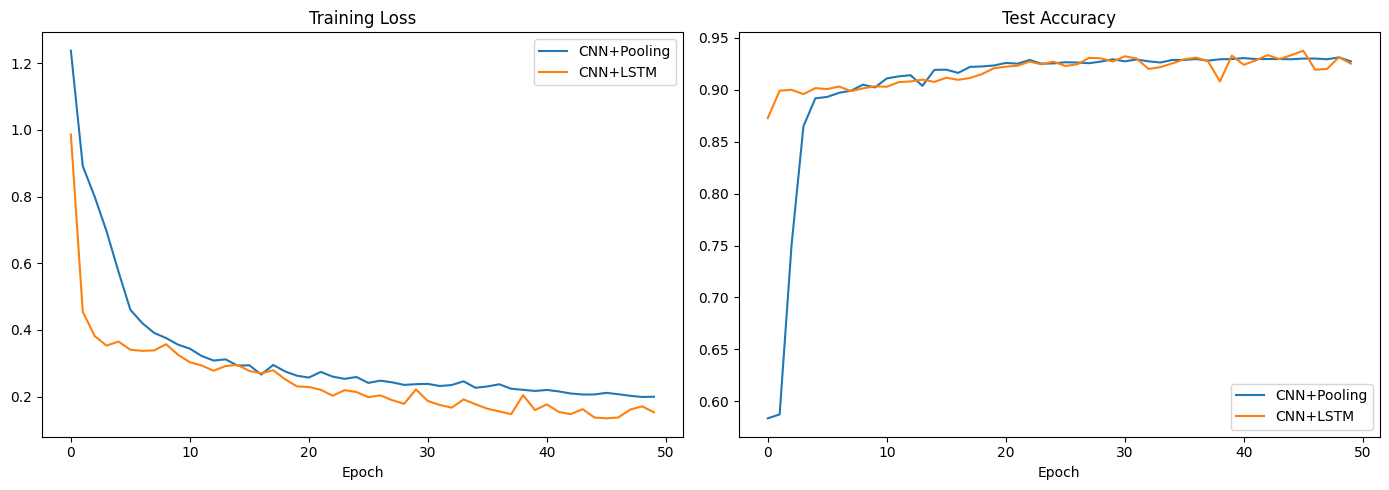


--- Final Results on ECG5000 ---
CNN+Pooling  | Acc: 0.9309 | Time: 11.0s | Params: 35909
CNN+LSTM     | Acc: 0.9373 | Time: 19.6s | Params: 300101


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pool_losses, label='CNN+Pooling')
axes[0].plot(lstm_losses, label='CNN+LSTM')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(pool_accs, label='CNN+Pooling')
axes[1].plot(lstm_accs, label='CNN+LSTM')
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n--- Final Results on ECG5000 ---")
print(f"CNN+Pooling  | Acc: {max(pool_accs):.4f} | Time: {pool_time:.1f}s | Params: {sum(p.numel() for p in cnn_pool.parameters())}")
print(f"CNN+LSTM     | Acc: {max(lstm_accs):.4f} | Time: {lstm_time:.1f}s | Params: {sum(p.numel() for p in cnn_lstm.parameters())}")

# Performance vs Sequence Length


Training with sequence length 20...
Epoch 10/50 | Loss: 0.2604 | Acc: 0.9173
Early stopping at epoch 19, best val_acc=0.9229
Epoch 10/50 | Loss: 0.3525 | Acc: 0.9033
Epoch 20/50 | Loss: 0.2195 | Acc: 0.9220
Epoch 30/50 | Loss: 0.1913 | Acc: 0.9202
Epoch 40/50 | Loss: 0.1574 | Acc: 0.9229
Epoch 50/50 | Loss: 0.1792 | Acc: 0.9198
Length 20 | CNN+Pooling: 0.9229 | CNN+LSTM: 0.9280

Training with sequence length 30...
Epoch 10/50 | Loss: 0.2708 | Acc: 0.9173
Epoch 20/50 | Loss: 0.2026 | Acc: 0.9182
Epoch 30/50 | Loss: 0.1803 | Acc: 0.9129
Epoch 40/50 | Loss: 0.1423 | Acc: 0.9247
Early stopping at epoch 49, best val_acc=0.9278
Epoch 10/50 | Loss: 0.3894 | Acc: 0.8656
Epoch 20/50 | Loss: 0.2549 | Acc: 0.9051
Epoch 30/50 | Loss: 0.1761 | Acc: 0.9249
Epoch 40/50 | Loss: 0.1408 | Acc: 0.9238
Early stopping at epoch 43, best val_acc=0.9260
Length 30 | CNN+Pooling: 0.9278 | CNN+LSTM: 0.9260

Training with sequence length 40...
Epoch 10/50 | Loss: 0.2834 | Acc: 0.9149
Epoch 20/50 | Loss: 0.2183 |

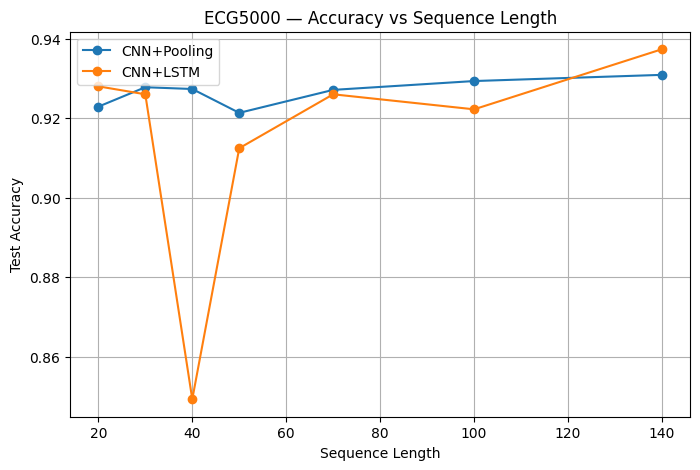

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lengths = [20, 30, 40, 50, 70, 100, 140]
pool_length_accs = []
lstm_length_accs = []

for length in lengths:
    print(f"\nTraining with sequence length {length}...")

    # Truncate
    X_train_short = X_train[:, :, :length]
    X_test_short  = X_test[:, :, :length]

    train_loader_s = DataLoader(TensorDataset(X_train_short, y_train), batch_size=32, shuffle=True)
    test_loader_s  = DataLoader(TensorDataset(X_test_short, y_test),   batch_size=32, shuffle=False)

    # CNN+Pooling
    set_seed(789)
    model_pool = CNN_TemporalPooling(NUM_CLASSES).to(device)
    filename = ""
    if length == 40 or length == 140:
        filename=f"pool_{length}"
    _, accs_pool, _, _ = train_model(model_pool, train_loader_s, test_loader_s, epochs=50, filename=filename)
    pool_length_accs.append(max(accs_pool))

    # CNN+LSTM
    set_seed(789)
    model_lstm = CNN_LSTM(NUM_CLASSES).to(device)
    filename = ""
    if length == 40 or length == 140:
        filename=f"lstm_{length}"
    _, accs_lstm, _, _ = train_model(model_lstm, train_loader_s, test_loader_s, epochs=50, filename=filename)
    lstm_length_accs.append(max(accs_lstm))

    print(f"Length {length} | CNN+Pooling: {pool_length_accs[-1]:.4f} | CNN+LSTM: {lstm_length_accs[-1]:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(lengths, pool_length_accs, marker='o', label='CNN+Pooling')
plt.plot(lengths, lstm_length_accs, marker='o', label='CNN+LSTM')
plt.xlabel('Sequence Length')
plt.ylabel('Test Accuracy')
plt.title('ECG5000 — Accuracy vs Sequence Length')
plt.legend()
plt.grid(True)
plt.show()

# Performance vs Noise Level

Sigma 0.0 | CNN+Pooling: 0.9271 | CNN+LSTM: 0.9249
Sigma 0.1 | CNN+Pooling: 0.9267 | CNN+LSTM: 0.9238
Sigma 0.3 | CNN+Pooling: 0.9209 | CNN+LSTM: 0.9136
Sigma 0.5 | CNN+Pooling: 0.8964 | CNN+LSTM: 0.8958
Sigma 1.0 | CNN+Pooling: 0.7056 | CNN+LSTM: 0.8493


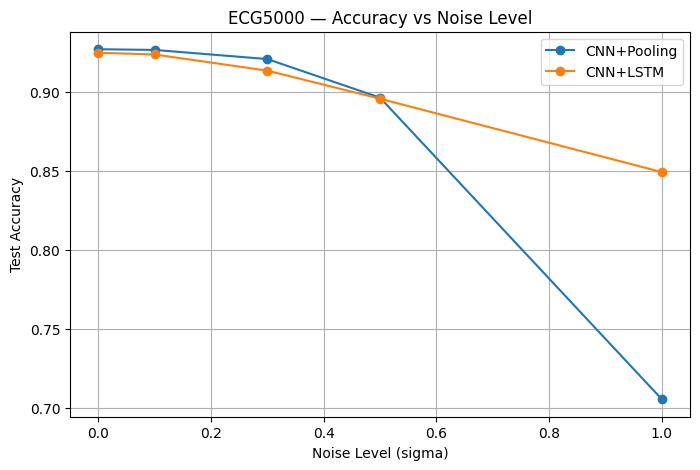

In [11]:
# Use the already trained models from Cell 7 — no retraining needed
# We are testing robustness of learned representations to noise

sigmas = [0.0, 0.1, 0.3, 0.5, 1.0]
pool_noise_accs = []
lstm_noise_accs = []

cnn_pool.eval()
cnn_lstm.eval()

for sigma in sigmas:
    pool_preds, lstm_preds, all_labels = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_noisy = X_batch.to(device) + sigma * torch.randn_like(X_batch).to(device)

            pool_pred = cnn_pool.to(device)(X_noisy).argmax(dim=1).cpu().numpy()
            lstm_pred = cnn_lstm.to(device)(X_noisy).argmax(dim=1).cpu().numpy()

            pool_preds.extend(pool_pred)
            lstm_preds.extend(lstm_pred)
            all_labels.extend(y_batch.numpy())

    pool_noise_accs.append(accuracy_score(all_labels, pool_preds))
    lstm_noise_accs.append(accuracy_score(all_labels, lstm_preds))
    print(f"Sigma {sigma:.1f} | CNN+Pooling: {pool_noise_accs[-1]:.4f} | CNN+LSTM: {lstm_noise_accs[-1]:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(sigmas, pool_noise_accs, marker='o', label='CNN+Pooling')
plt.plot(sigmas, lstm_noise_accs, marker='o', label='CNN+LSTM')
plt.xlabel('Noise Level (sigma)')
plt.ylabel('Test Accuracy')
plt.title('ECG5000 — Accuracy vs Noise Level')
plt.legend()
plt.grid(True)
plt.show()

# Summary table of all results

In [12]:
print("="*60)
print("FULL RESULTS SUMMARY — ECG5000")
print("="*60)

print("\n1. Baseline")
print(f"   CNN+Pooling : {max(pool_accs):.4f} | {pool_time:.1f}s | {sum(p.numel() for p in cnn_pool.parameters())} params")
print(f"   CNN+LSTM    : {max(lstm_accs):.4f} | {lstm_time:.1f}s | {sum(p.numel() for p in cnn_lstm.parameters())} params")

print("\n2. Accuracy vs Sequence Length")
print(f"   {'Length':<10} {'CNN+Pooling':<15} {'CNN+LSTM'}")
for l, p, q in zip(lengths, pool_length_accs, lstm_length_accs):
    print(f"   {l:<10} {p:<15.4f} {q:.4f}")

print("\n3. Accuracy vs Noise Level")
print(f"   {'Sigma':<10} {'CNN+Pooling':<15} {'CNN+LSTM'}")
for s, p, q in zip(sigmas, pool_noise_accs, lstm_noise_accs):
    print(f"   {s:<10} {p:<15.4f} {q:.4f}")

FULL RESULTS SUMMARY — ECG5000

1. Baseline
   CNN+Pooling : 0.9309 | 11.0s | 35909 params
   CNN+LSTM    : 0.9373 | 19.6s | 300101 params

2. Accuracy vs Sequence Length
   Length     CNN+Pooling     CNN+LSTM
   20         0.9229          0.9280
   30         0.9278          0.9260
   40         0.9273          0.8493
   50         0.9213          0.9124
   70         0.9271          0.9260
   100        0.9293          0.9222
   140        0.9309          0.9373

3. Accuracy vs Noise Level
   Sigma      CNN+Pooling     CNN+LSTM
   0.0        0.9271          0.9249
   0.1        0.9267          0.9238
   0.3        0.9209          0.9136
   0.5        0.8964          0.8958
   1.0        0.7056          0.8493
